In [1]:
!pip install -q opencv-python-headless transformers torch tqdm pillow
!apt-get -qq install ffmpeg -y

In [2]:
import cv2
import numpy as np
import torch
from transformers import pipeline
from PIL import Image
from scipy.spatial import cKDTree
import glob
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print("using", device)

pipe = pipeline(task="depth-estimation", model="depth-anything/Depth-Anything-V2-Small-hf", device=device)

using cpu


config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 99.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

In [13]:
video_path = "sample.mp4"

In [4]:
# pull frames out of the video, 2 fps is usually enough overlap for stitching
!rm -f frame_*.jpg
fps = 2
!ffmpeg -i "{video_path}" -vf fps={fps} -qscale:v 2 frame_%03d.jpg -hide_banner -loglevel error

frame_files = sorted(glob.glob("frame_*.jpg"))
print(len(frame_files), "frames extracted")

26 frames extracted


In [5]:
images = []
for f in tqdm(frame_files):
    img = cv2.imread(f)
    if img is not None:
        images.append(img)

print("stitching panorama, this can take a bit...")
stitcher = cv2.Stitcher_create()
status, stitched = stitcher.stitch(images)

if status != cv2.Stitcher_OK:
    print("stitching failed, frames probably don't overlap enough")

100%|██████████| 26/26 [00:00<00:00, 267.61it/s]

stitching panorama, this can take a bit...


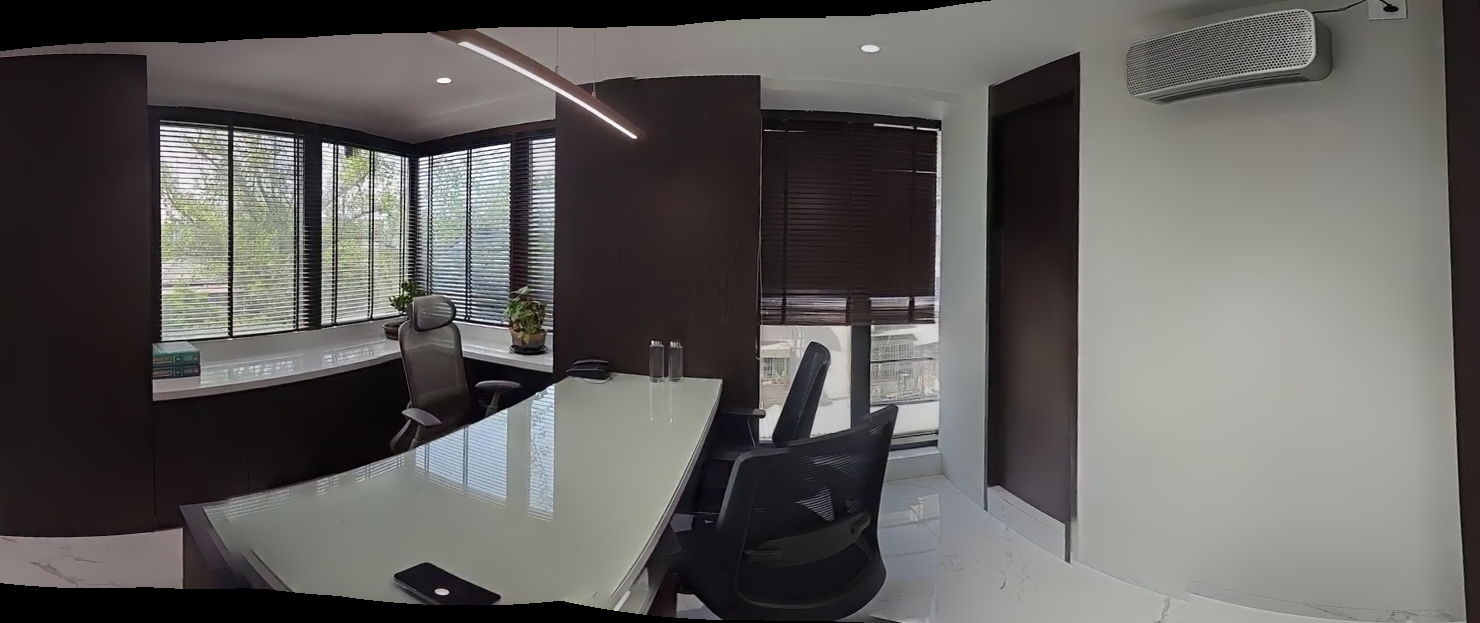

In [6]:
# crop out the black borders left after stitching
gray = cv2.cvtColor(stitched, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if contours:
    c = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(c)
    pad_x, pad_y = int(w * 0.04), int(h * 0.04)
    stitched = stitched[y+pad_y : y+h-pad_y, x+pad_x : x+w-pad_x]

pano_img = Image.fromarray(cv2.cvtColor(stitched, cv2.COLOR_BGR2RGB))
width, height = pano_img.size
pano_img

In [7]:
print("running depth estimation...")
depth_res = pipe(pano_img)
raw_tensor = depth_res["predicted_depth"].squeeze().cpu().numpy()
disparity_map = cv2.resize(raw_tensor, (width, height), interpolation=cv2.INTER_CUBIC)

depth_map = 1.0 / (disparity_map + 1e-5)

# clip extremes so a couple of noisy pixels dont wreck the scale
d_min, d_max = np.percentile(depth_map, 5), np.percentile(depth_map, 95)
depth_map = np.clip(depth_map, d_min, d_max)
depth_map = (depth_map - d_min) / (d_max - d_min + 1e-5)

# scale so walls end up roughly 1 to 6 units away
depth_map = (depth_map * 5.0) + 1.0
depth_map = cv2.bilateralFilter(depth_map, d=9, sigmaColor=0.1, sigmaSpace=10)

running depth estimation...


In [8]:
u, v = np.meshgrid(np.arange(width), np.arange(height))

fov_x = 140.0 * (np.pi / 180.0)   # bump this up if the room feels too closed in
theta = (u / width - 0.5) * fov_x
focal_length = width / fov_x

X = depth_map * np.sin(theta)
Z = depth_map * np.cos(theta)
Y = -(v - height / 2.0) * (depth_map / focal_length)

points = np.stack((X, Y, Z), axis=-1).reshape(-1, 3)
colors = (np.array(pano_img) / 255.0).reshape(-1, 3)
# print(points.shape, colors.shape)

In [9]:
# simple statistical outlier removal, no open3d needed for this
# downsample a bit first or this KDTree query gets slow on huge panoramas
step = 2
points = points[::step]
colors = colors[::step]

tree = cKDTree(points)
dists, _ = tree.query(points, k=21)   # self + 20 neighbors
mean_dist = dists[:, 1:].mean(axis=1)

thresh = mean_dist.mean() + 2.0 * mean_dist.std()
mask = mean_dist < thresh

points = points[mask]
colors = colors[mask]
print(points.shape[0], "points after cleanup")

449021 points after cleanup


In [10]:
# write out a plain ascii ply, opens fine in meshlab / cloudcompare
colors_255 = (colors * 255).astype(np.uint8)
vertex_data = np.hstack((points, colors_255))

header = (
    "ply\n"
    "format ascii 1.0\n"
    f"element vertex {vertex_data.shape[0]}\n"
    "property float x\n"
    "property float y\n"
    "property float z\n"
    "property uchar red\n"
    "property uchar green\n"
    "property uchar blue\n"
    "end_header\n"
)

with open("room_cylindrical.ply", "w") as f:
    f.write(header)
    np.savetxt(f, vertex_data, fmt="%.4f %.4f %.4f %d %d %d")

print("saved room_cylindrical.ply")

saved room_cylindrical.ply


In [11]:
try:
    from google.colab import files
    files.download('room_cylindrical.ply')
except Exception:
    print('Point cloud successfully saved locally: room_cylindrical.ply')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>